In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
#Reading .csv files
features = pd.read_csv("smartphone_battery_features.csv")
targets = pd.read_csv("smartphone_battery_targets.csv")


In [13]:
#Printing Columns and there datatype
print("\nFeature Columns:")
print(features.columns)

print("\nFeature Data Types:")
print(features.dtypes)

print("\nTarget Columns:")
print(targets.columns)

print("\nTarget Data Types:")
print(targets.dtypes)


Feature Columns:
Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index'],
      dtype='str')

Feature Data Types:
Device_ID                               str
device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
background_app_usage_level              str
signal_

In [14]:
#First 5 elements
print("\nFirst 5 Rows:")
print(features.head())


First 5 Rows:
                              Device_ID  device_age_months  \
0  207dd94c-0430-43aa-b388-4893447e628e                 38   
1  3f4d1d33-ba89-4814-a168-7b4cc75be26b                 28   
2  b4adca05-564f-4b70-ab69-e8d66e656463                 14   
3  4147e039-31b7-480a-bbc9-03cd0f66e9f1                 42   
4  3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5                  7   

   battery_capacity_mah  avg_screen_on_hours_per_day  \
0                  4500                          7.1   
1                  3000                          6.8   
2                  3000                          7.2   
3                  3000                          5.5   
4                  3000                          7.6   

   avg_charging_cycles_per_week  avg_battery_temp_celsius  \
0                          11.4                      34.8   
1                          10.3                      35.4   
2                          11.2                      29.4   
3                           8.3

In [15]:
#Checking Missing Value
print("\nMissing Values:")
print(features.isnull().sum())


Missing Values:
Device_ID                           0
device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
dtype: int64


In [16]:
#Filling Missing Values
features = features.fillna(features.mean(numeric_only=True))
features = features.fillna("Unknown")

In [17]:
#Dropping Dulicate Rows
features = features.drop_duplicates()
targets = targets.drop_duplicates()

In [18]:
#Merging Of Data
data = pd.merge(features, targets, on="Device_ID")
print("\nFinal Dataset Shape:", data.shape)
print("\nFinal Columns:")
print(data.columns)


Final Dataset Shape: (5000, 17)

Final Columns:
Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index', 'current_battery_health_percent',
       'recommended_action'],
      dtype='str')


In [19]:
#Encoding
le = LabelEncoder()
categorical_cols = ["background_app_usage_level", "signal_strength_avg"]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
       device_age_months  battery_capacity_mah  avg_screen_on_hours_per_day  \
count        5000.000000           5000.000000                  5000.000000   
mean           24.232400           4134.700000                     5.514120   
std            14.138004            745.061698                     1.974704   
min             0.000000           3000.000000                     1.000000   
25%            12.000000           4000.000000                     4.200000   
50%            24.000000           4500.000000                     5.500000   
75%            36.000000           5000.000000                     6.900000   
max            48.000000           5000.000000                    12.000000   

       avg_charging_cycles_per_week  avg_battery_temp_celsius  \
count                    5000.00000               5000.000000   
mean                        8.33224                 31.907360   
std                         3.03454                  2.544528   
min   

In [20]:
# Scaling
scaler = StandardScaler()

features_scaled = scaler.fit_transform(
    data.drop(["Device_ID", "current_battery_health_percent", "recommended_action"], axis=1)
)

features_scaled = pd.DataFrame(
    features_scaled,
    columns=data.drop(["Device_ID", "current_battery_health_percent", "recommended_action"], axis=1).columns
)

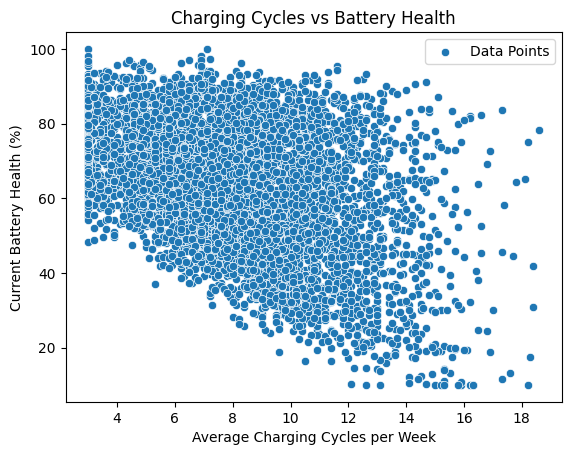

In [21]:
#Scatter Plot Analysis
sns.scatterplot(
    x="avg_charging_cycles_per_week",
    y="current_battery_health_percent",
    data=data,
    label="Data Points"
)

plt.title("Charging Cycles vs Battery Health")
plt.xlabel("Average Charging Cycles per Week")
plt.ylabel("Current Battery Health (%)")
plt.legend()
plt.show()

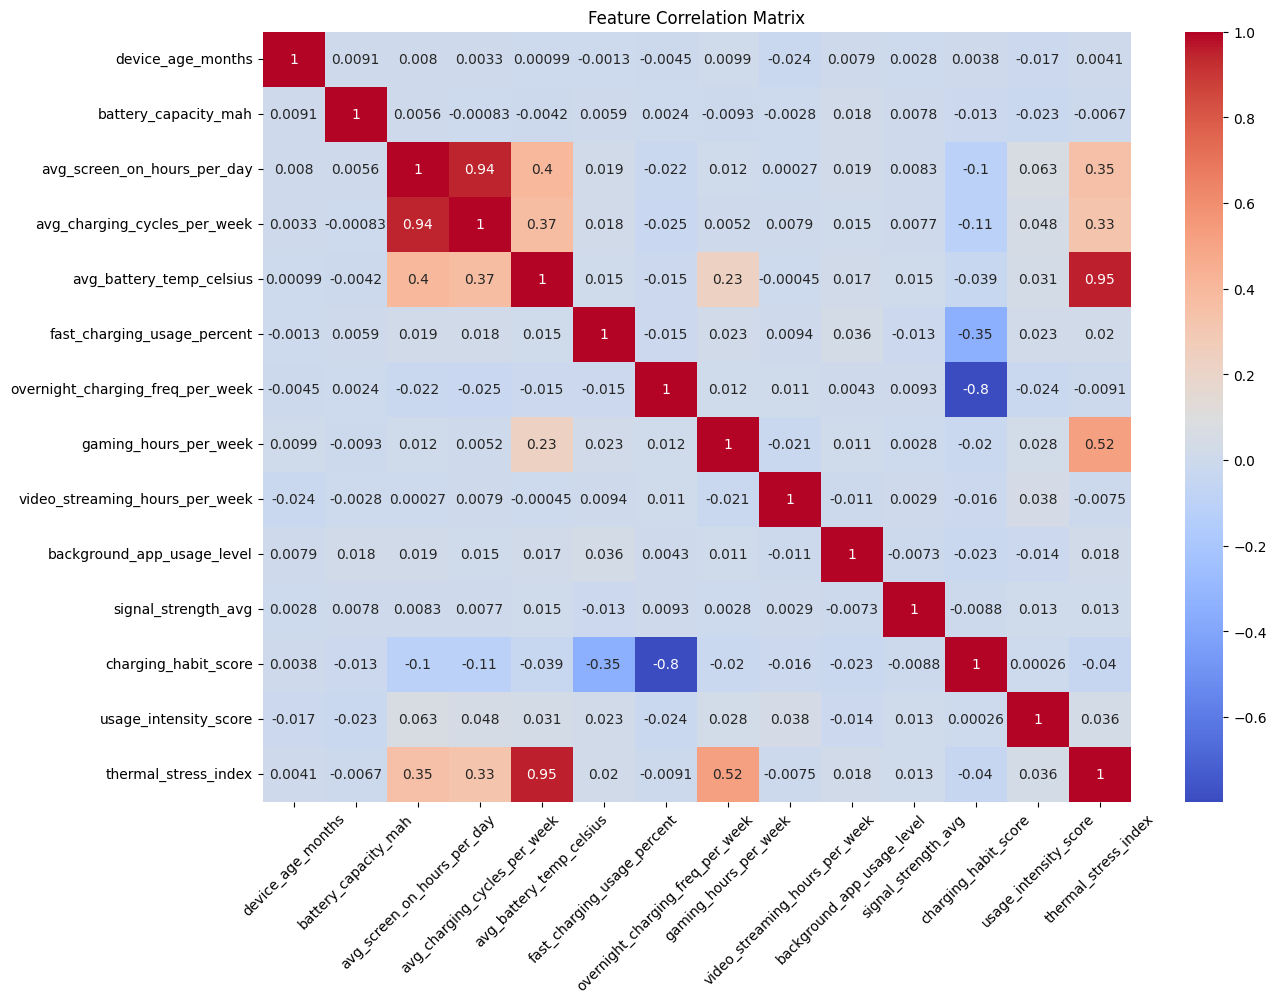

In [22]:
#Correlational Analysis
plt.figure(figsize=(14,10))
sns.heatmap(features_scaled.corr(), annot=True,cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15080\3320731157.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Keep Using", "Replace Battery", "Change Phone"])


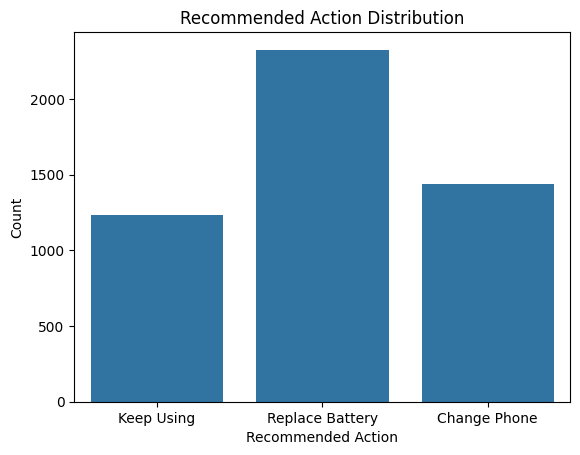

In [23]:
ax = sns.countplot(x="recommended_action", data=data)

plt.title("Recommended Action Distribution")
plt.xlabel("Recommended Action")
plt.ylabel("Count")

ax.set_xticklabels(["Keep Using", "Replace Battery", "Change Phone"])

plt.show()

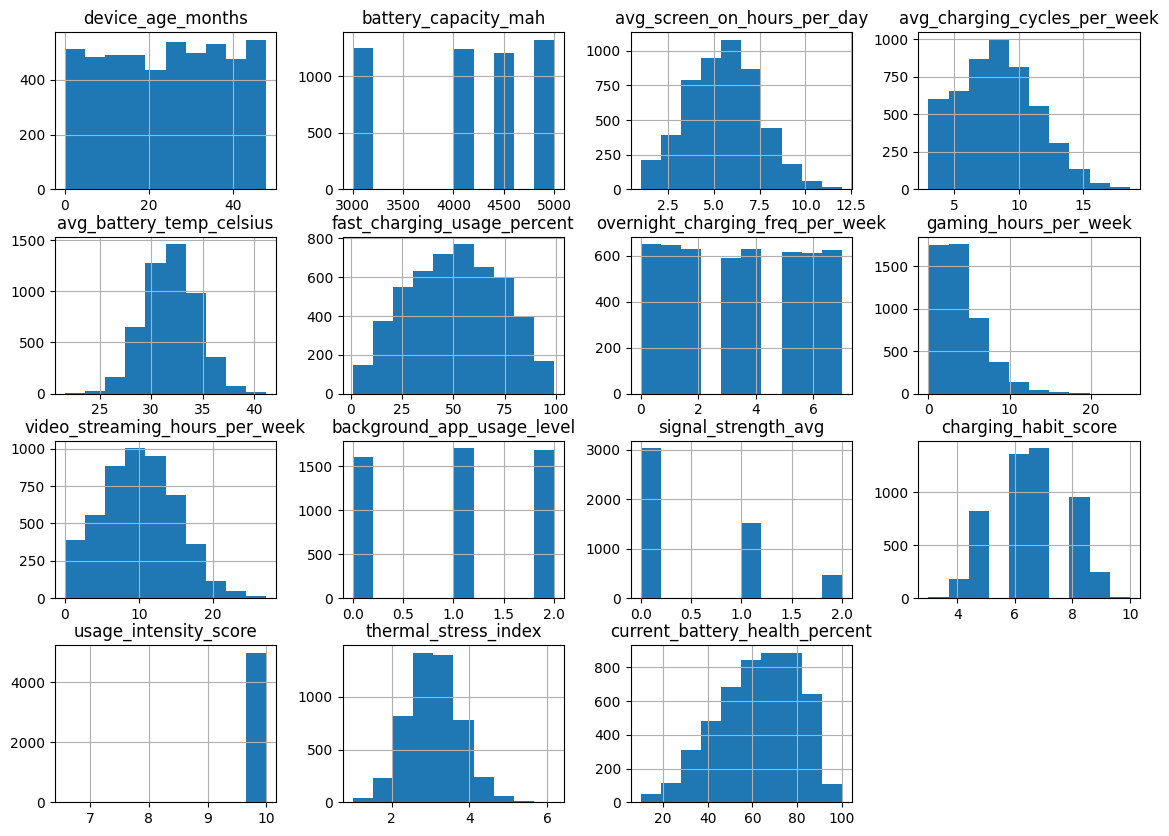

In [24]:
#Histogram Plotting
data.hist(figsize=(14,10))
plt.show()

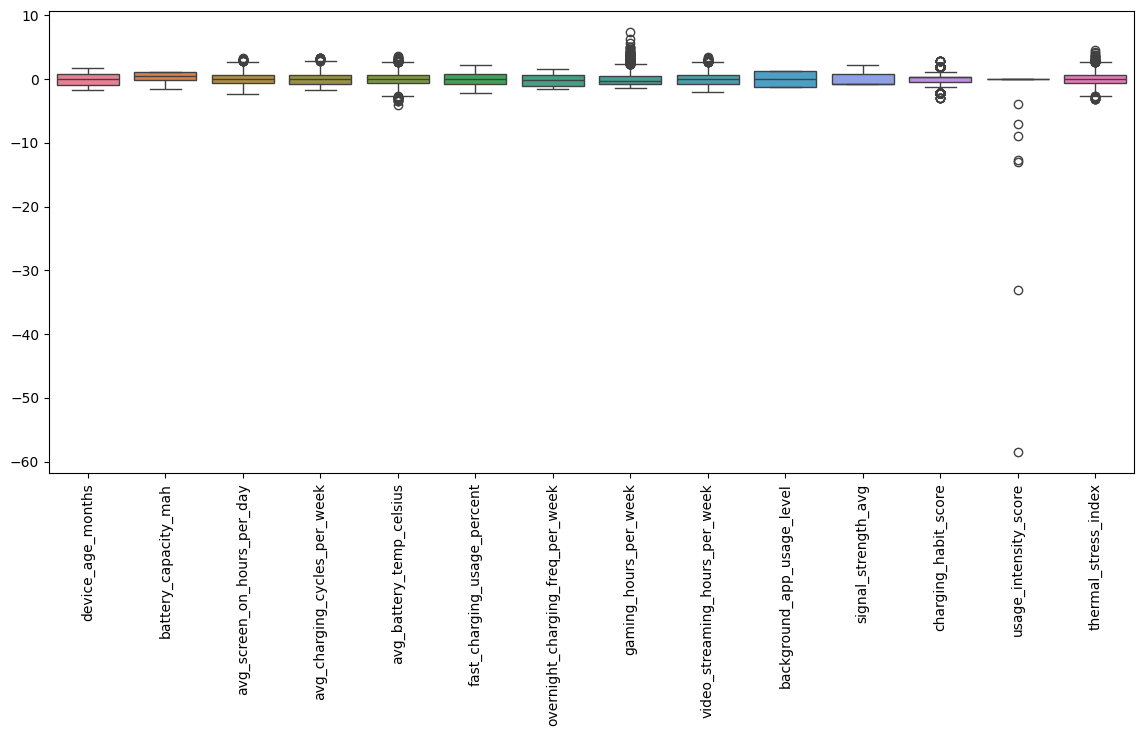

In [25]:
#Outlier Detection
plt.figure(figsize=(14,6))
sns.boxplot(data=features_scaled)
plt.xticks(rotation=90)
plt.show()

In [26]:
X = data.drop(["current_battery_health_percent", "Device_ID", "recommended_action"], axis=1)
y = data["current_battery_health_percent"]

In [27]:
#Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# train model
model = LinearRegression()
model.fit(X_train, y_train)
print(X.columns)

Index(['device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index'],
      dtype='str')


In [29]:
# prediction
y_pred = model.predict(X_test)

In [30]:
# evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# print results
print("Model Evaluation Metrics:")
print("---------------------------")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R2 Score): {r2:.4f}")

Model Evaluation Metrics:
---------------------------
MAE  (Mean Absolute Error): 3.6777
MSE  (Mean Squared Error): 21.9696
RMSE (Root Mean Squared Error): 4.6872
R²   (R2 Score): 0.9298


In [31]:
mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

data["background_app_usage_level"] = data["background_app_usage_level"].map(mapping)

In [32]:
import joblib

joblib.dump(model, "battery_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print(X.columns.tolist())

['device_age_months', 'battery_capacity_mah', 'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week', 'avg_battery_temp_celsius', 'fast_charging_usage_percent', 'overnight_charging_freq_per_week', 'gaming_hours_per_week', 'video_streaming_hours_per_week', 'background_app_usage_level', 'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score', 'thermal_stress_index']


In [33]:
model = joblib.load("battery_model.pkl")
scaler = joblib.load("scaler.pkl")

In [37]:
import streamlit as st

age = st.slider("Device Age (months)", 0, 60)
usage = st.slider("Daily Usage (hours)", 0, 12)

if st.button("Predict"):
    input_data = pd.DataFrame([[age, usage]], columns=X.columns)
    input_scaled = scaler.transform(input_data)
    pred = model.predict(input_scaled)
    st.write("Battery Health:", pred[0])

2026-03-25 19:03:30.887 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:30.889 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:30.891 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:30.892 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:30.894 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-03-25 19:03:30.895 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

In [38]:
import streamlit as st

age = st.slider("Device Age (months)", 0, 60)
usage = st.slider("Daily Usage (hours)", 0, 12)

if st.button("Predict"):
    input_data = pd.DataFrame([[age, usage]], columns=X.columns)
    input_scaled = scaler.transform(input_data)
    pred = model.predict(input_scaled)
    st.write("Battery Health:", pred[0])

2026-03-25 19:03:39.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 19:03:39.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [39]:

# initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# train
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

In [40]:

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("---------------------------")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Random Forest Performance:
---------------------------
MAE  : 2.9404
MSE  : 13.3346
RMSE : 3.6517
R²   : 0.9574


In [41]:
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2)

Linear Regression R2: 0.9298335708757443
Random Forest R2: 0.9574119014885526


In [42]:
import joblib

joblib.dump(rf_model, "battery_rf_model.pkl")
rf_model = joblib.load("battery_model.pkl")